<h3>Лабораторная работа №3<p>
Выявление информативных признаков и построение системы распознавания голосовых команд<p>
<h5>Енгоян Сергей Ключковский Даниил А-01м-25

In [49]:
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import os

In [50]:
def load_audio_segments(base_path):
    """
    Загружает аудио сегменты из папок в структурированный формат
    """
    data = []
    
    # Проходим по всем папкам
    for folder_name in os.listdir(base_path):
        folder_path = os.path.join(base_path, folder_name)
        
        if os.path.isdir(folder_path):
            print(f"Загружаем файлы из папки: {folder_name}")
            
            # Проходим по всем файлам в папке
            for file_name in sorted(os.listdir(folder_path)):
                if file_name.startswith(folder_name) and file_name.endswith('.wav'):
                    file_path = os.path.join(folder_path, file_name)
                    
                    try:
                        # Загружаем аудиофайл
                        audio, sr = librosa.load(file_path, sr=22050)
                        
                        # Извлекаем номер сегмента из имени файла
                        segment_num = int(file_name.split('_')[-1].split('.')[0])
                        
                        data.append({
                            'audio': audio,
                            'sampling_rate': sr,
                            'label': folder_name,
                            'segment_number': segment_num,
                            'duration': len(audio) / sr
                        })
                        
                    except Exception as e:
                        print(f"Ошибка при загрузке {file_path}: {e}")
    
    # Создаем DataFrame
    df = pd.DataFrame(data)
    return df

base_path = "SOUNDS/"
audio_df = load_audio_segments(base_path)

print(f"Загружено {len(audio_df)} файлов")
print("Уникальные классы:", audio_df['label'].unique())
print(audio_df.head())

Загружаем файлы из папки: distributivi
Загружаем файлы из папки: dokumenti
Загружаем файлы из папки: filmi
Загружаем файлы из папки: fotografii
Загружаем файлы из папки: igri
Загружаем файлы из папки: knigi
Загружаем файлы из папки: musika
Загружаем файлы из папки: proekti
Загружаем файлы из папки: zagruzki
Загружено 135 файлов
Уникальные классы: ['distributivi' 'dokumenti' 'filmi' 'fotografii' 'igri' 'knigi' 'musika'
 'proekti' 'zagruzki']
                                               audio  sampling_rate  \
0  [0.0008544922, 0.009460449, 0.012878418, 0.006...          22050   
1  [-0.00015258789, -0.00061035156, -0.0011901855...          22050   
2  [-0.019927979, -0.01473999, -0.011810303, -0.0...          22050   
3  [0.006591797, 0.007385254, 0.0078125, 0.008239...          22050   
4  [-9.1552734e-05, -9.1552734e-05, -3.0517578e-0...          22050   

          label  segment_number  duration  
0  distributivi               1  1.047664  
1  distributivi               2  1.24222

In [51]:
audio_df['label'].value_counts()

label
distributivi    15
dokumenti       15
filmi           15
fotografii      15
igri            15
knigi           15
musika          15
proekti         15
zagruzki        15
Name: count, dtype: int64

In [52]:
def extract_mfcc_features(audio_df, n_mfcc=13, frame_length=2048, hop_length=512):
    """
    Извлекает MFCC признаки из аудио сегментов
    """
    
    mfcc_features = []
    
    for idx, row in audio_df.iterrows():
        audio = row['audio']
        sr = row['sampling_rate']
        
        # Извлекаем MFCC признаки
        mfcc = librosa.feature.mfcc(
            y=audio, 
            sr=sr, 
            n_mfcc=n_mfcc,
            n_fft=frame_length,
            hop_length=hop_length
        )
        mfcc = mfcc.ravel(order="F")
        
        mfcc_features.append({
            'label': row['label'],
            'audio' : row['audio'],
            'segment_number': row['segment_number'],
            'mfcc_matrix': mfcc,           # Полная матрица MFCC (13 x N_frames)
            'original_duration': row['duration']
        })
        
    return pd.DataFrame(mfcc_features)

# Использование функции
print("Извлечение MFCC признаков...")
mfcc_features_df = extract_mfcc_features(audio_df, n_mfcc=13)



print("\nПервые 5 записей:")
print(mfcc_features_df[['mfcc_matrix']].head())

Извлечение MFCC признаков...

Первые 5 записей:
                                         mfcc_matrix
0  [-398.4823, 99.40163, -1.0410377, 95.926994, -...
1  [-513.7162, 177.79803, 46.862354, 31.449303, 2...
2  [-351.7988, 76.669556, 16.731697, 76.964676, -...
3  [-491.99164, 148.94333, 43.237625, 43.68419, 2...
4  [-531.1481, 151.50888, 41.41855, 25.740913, 17...


In [53]:
mfcc_features_df['mfcc_matrix'].iloc[0]

array([-3.98482300e+02,  9.94016266e+01, -1.04103768e+00,  9.59269943e+01,
       -1.75659790e+01,  2.87909813e+01, -1.02995634e+01,  2.23651409e+01,
        6.59477711e-01, -2.15850449e+01, -1.38872504e+00, -2.24123669e+01,
       -2.60844016e+00, -3.87870239e+02,  9.64888916e+01, -6.47177362e+00,
        1.05562599e+02, -2.40544472e+01,  1.60605125e+01, -1.84152374e+01,
        2.27376976e+01,  1.10812254e+01, -2.35651627e+01, -3.60208845e+00,
       -2.05136871e+01, -5.74638367e+00, -4.08530518e+02,  9.10482407e+01,
        2.14417195e+00,  1.04799271e+02, -2.54919815e+01,  7.97036982e+00,
       -2.76017647e+01,  1.43696489e+01,  7.01466942e+00, -2.77298679e+01,
       -1.09690838e+01, -1.76625023e+01, -1.40559216e+01, -3.93341919e+02,
        9.89508286e+01, -7.87777305e-02,  1.03692474e+02, -1.39679737e+01,
        9.58006954e+00, -3.10762901e+01,  2.54226418e+01, -2.89498353e+00,
       -3.72783127e+01, -1.52500286e+01, -1.77440338e+01, -1.46790342e+01,
       -3.56973541e+02,  

In [54]:
from sklearn.model_selection import train_test_split
import numpy as np

def split_dataset(mfcc_features_df, test_size=0.2, random_state=42):
    """
    Разбивает данные на обучающую и тестовую выборки
    """
    # Проверяем, что у нас есть 15 сегментов
    unique_segments = mfcc_features_df['segment_number'].unique()
    print(f"Уникальные номера сегментов: {sorted(unique_segments)}")
    print(f"Всего сегментов: {len(unique_segments)}")
    
    # Группируем по меткам (классам)
    unique_labels = mfcc_features_df['label'].unique()
    print(f"Уникальные классы: {unique_labels}")
    
    # Создаем списки для train и test
    train_indices = []
    test_indices = []
    
    # Для каждого класса выбираем тестовые сегменты
    for label in unique_labels:
        label_data = mfcc_features_df[mfcc_features_df['label'] == label]
        
        # Получаем все сегменты для этого класса
        segments = sorted(label_data['segment_number'].unique())
        print(f"Класс {label}: сегменты {segments}")
        
        # Выбираем тестовые сегменты (примерно 20% от 15 = 3 сегмента)
        test_segments = sorted(np.random.choice(segments, size=3, replace=False))
        train_segments = [s for s in segments if s not in test_segments]
        
        print(f"  Train сегменты: {train_segments}")
        print(f"  Test сегменты: {test_segments}")
        
        # Добавляем индексы в соответствующие списки
        train_indices.extend(label_data[label_data['segment_number'].isin(train_segments)].index.tolist())
        test_indices.extend(label_data[label_data['segment_number'].isin(test_segments)].index.tolist())
    
    # Создаем train и test DataFrame
    train_df = mfcc_features_df.loc[train_indices].reset_index(drop=True)
    test_df = mfcc_features_df.loc[test_indices].reset_index(drop=True)
    
    return train_df, test_df

In [55]:
print("Разбиваем данные на обучающую и тестовую выборки...")
train_df, test_df = split_dataset(mfcc_features_df)

print(f"\nРазмер обучающей выборки: {len(train_df)}")
print(f"Размер тестовой выборки: {len(test_df)}")
print(f"Соотношение train/test: {len(train_df)/len(mfcc_features_df):.2f}/{len(test_df)/len(mfcc_features_df):.2f}")

# Проверяем распределение классов в обеих выборках
print("\nРаспределение классов в обучающей выборке:")
print(train_df['label'].value_counts())

print("\nРаспределение классов в тестовой выборке:")
print(test_df['label'].value_counts())

Разбиваем данные на обучающую и тестовую выборки...
Уникальные номера сегментов: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Всего сегментов: 15
Уникальные классы: ['distributivi' 'dokumenti' 'filmi' 'fotografii' 'igri' 'knigi' 'musika'
 'proekti' 'zagruzki']
Класс distributivi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 14, 15]
  Test сегменты: [1, 7, 13]
Класс dokumenti: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14]
  Test сегменты: [3, 13, 15]
Класс filmi: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 4, 6, 7, 8, 9, 10, 11, 12, 13, 15]
  Test сегменты: [3, 5, 14]
Класс fotografii: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
  Train сегменты: [1, 2, 3, 5, 6, 7, 9, 10, 11, 12, 13, 15]
  Test сегменты: [4, 8, 14]
Класс igri: сегменты [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14,

Подготовка данных для DTW...
Обучающая выборка: 108 примеров
Тестовая выборка: 27 примеров

Запуск DTW 1-NN классификации...
Обработано тестовых примеров: 10/27
Обработано тестовых примеров: 20/27
Обработано тестовых примеров: 27/27

Точность DTW (1-NN): 0.7407 (74.07%)

Отчёт по классификации:
              precision    recall  f1-score   support

distributivi       1.00      0.33      0.50         3
   dokumenti       1.00      1.00      1.00         3
       filmi       0.50      0.33      0.40         3
  fotografii       1.00      1.00      1.00         3
        igri       0.40      0.67      0.50         3
       knigi       1.00      0.67      0.80         3
      musika       1.00      1.00      1.00         3
     proekti       0.75      1.00      0.86         3
    zagruzki       0.50      0.67      0.57         3

    accuracy                           0.74        27
   macro avg       0.79      0.74      0.74        27
weighted avg       0.79      0.74      0.74        27


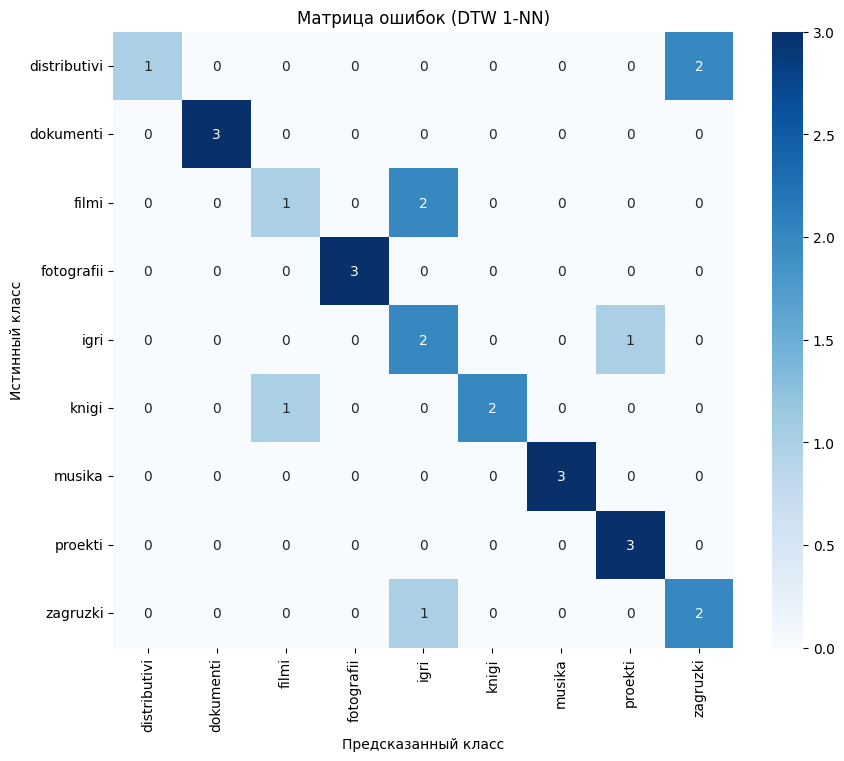

In [57]:
import numpy as np
from dtw import dtw
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# --- Преобразуем mfcc_matrix (плоский вектор) обратно в матрицу (n_mfcc x n_frames) ---
def reshape_mfcc(mfcc_flat, n_mfcc=13):
    n_coeffs = len(mfcc_flat)
    n_frames = n_coeffs // n_mfcc
    mfcc_flat = mfcc_flat[:n_frames * n_mfcc]  # обрезаем лишнее
    return mfcc_flat.reshape(n_mfcc, n_frames)

# --- DTW расстояние между двумя MFCC последовательностями ---
def dtw_distance(mfcc1, mfcc2):
    x = mfcc1.T  # (n_frames, n_mfcc)
    y = mfcc2.T  # (n_frames, n_mfcc)
    
    dtw_result = dtw(x, y, dist_method='euclidean')
    return dtw_result.distance

# --- 1-NN DTW классификатор ---
def dtw_knn_predict(X_train, y_train, X_test, k=1):
    y_pred = []
    for i, test_mfcc_flat in enumerate(X_test):
        test_mfcc = reshape_mfcc(test_mfcc_flat)
        distances = []
        for train_mfcc_flat, label in zip(X_train, y_train):
            train_mfcc = reshape_mfcc(train_mfcc_flat)
            dist = dtw_distance(train_mfcc, test_mfcc)
            distances.append((dist, label))
        
        # Сортируем по расстоянию и берём k ближайших
        distances.sort(key=lambda x: x[0])
        nearest_labels = [label for _, label in distances[:k]]
        
        # Голосование
        pred_label = max(set(nearest_labels), key=nearest_labels.count)
        y_pred.append(pred_label)
        
        if (i+1) % 10 == 0 or i == len(X_test) - 1:
            print(f"Обработано тестовых примеров: {i+1}/{len(X_test)}")
    
    return np.array(y_pred)

# --- Подготовка данных ---
print("Подготовка данных для DTW...")

# Извлекаем MFCC матрицы (в плоском виде, но будем reshaping)
X_train = train_df['mfcc_matrix'].values
y_train = train_df['label'].values

X_test = test_df['mfcc_matrix'].values
y_test = test_df['label'].values

print(f"Обучающая выборка: {len(X_train)} примеров")
print(f"Тестовая выборка: {len(X_test)} примеров")

# --- Запуск классификации ---
print("\nЗапуск DTW 1-NN классификации...")
y_pred = dtw_knn_predict(X_train, y_train, X_test, k=1)

# --- Оценка ---
accuracy = accuracy_score(y_test, y_pred)
print(f"\nТочность DTW (1-NN): {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\nОтчёт по классификации:")
print(classification_report(y_test, y_pred))

# --- Матрица ошибок ---
cm = confusion_matrix(y_test, y_pred, labels=sorted(np.unique(y_train)))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(np.unique(y_train)),
            yticklabels=sorted(np.unique(y_train)))
plt.title('Матрица ошибок (DTW 1-NN)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()